## Hierarchical Clustering for Customer Segmentation
Goal: Uncover hidden customer segments within demographic and behavioral data.





2.1 Data Loading and Exploration:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA # For visualization if needed


df = pd.read_csv('/content/segmentation_data.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


This code loads a new dataset into a pandas DataFrame and then inspects its structure and contents. This step confirms if the data loaded correctly, helps identify feature types and checks for any immediate data quality issues.

In [ ]:
print(df.shape)
print(df.dtypes)

(2000, 8)
ID                 int64
Sex                int64
Marital status     int64
Age                int64
Education          int64
Income             int64
Occupation         int64
Settlement size    int64
dtype: object


1.2 Scale Data:

In [ ]:
#drop unnessecary variables

df = df.drop(columns=['ID', 'Sex', 'Education', 'Marital status', 'Occupation', 'Settlement size'], errors='ignore')

print(df.shape)
print(df.dtypes)

#scale data

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head()

(2000, 2)
Age       int64
Income    int64
dtype: object


,Age,Income
0,2.653614,0.097524
1,-1.187132,0.782654
2,1.117316,-0.833202
3,0.775916,1.328386
4,1.458716,0.736932


This code cleans the dataset by removing unnecessary variables that don’t add value to segmentation to reduce noise. It then standardizes the remaining features using StandardScaler so all variables are on the same scale.

1.3 Agglomerative Hierarchical Clustering:

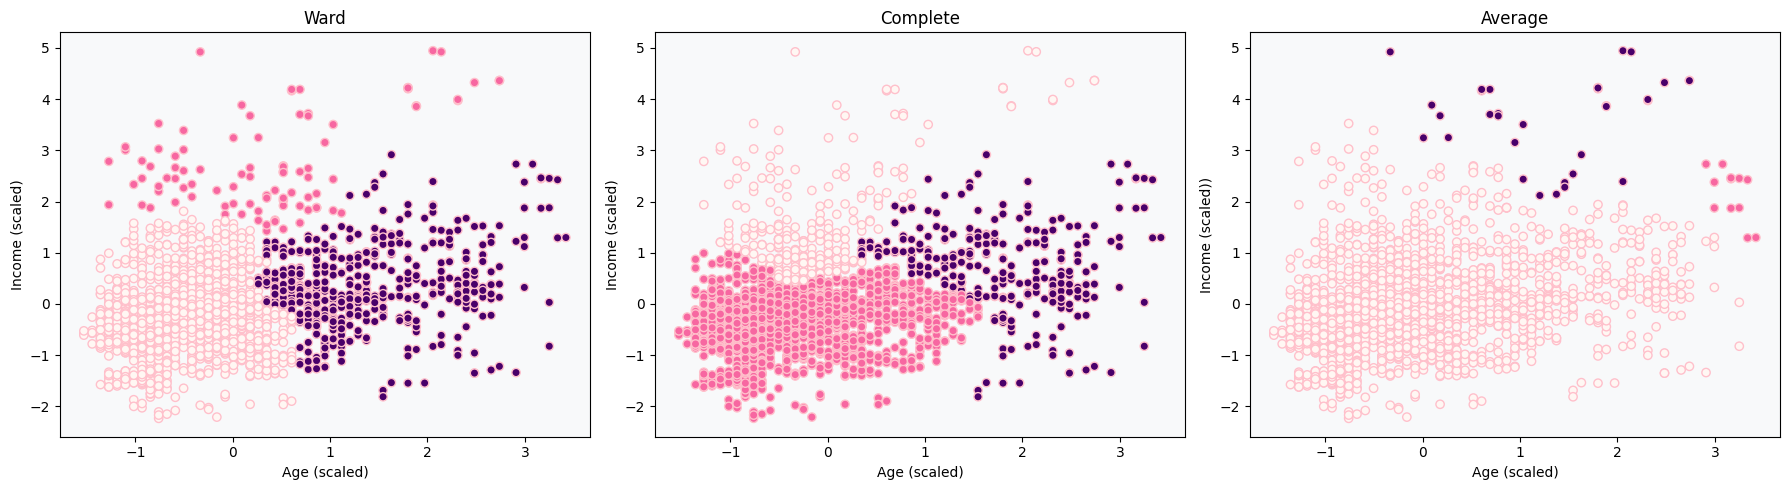

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

ward_model = linkage(df_scaled, method='ward')
complete_model = linkage(df_scaled, method='complete')
average_model = linkage(df_scaled, method='average')

#Cluster Labels

ward_labels = fcluster(ward_model, t=3, criterion='maxclust')
complete_labels = fcluster(complete_model, t=3, criterion='maxclust')
average_labels = fcluster(average_model, t=3, criterion='maxclust')

#Save labels

df['Ward'] = ward_labels
df['Complete'] = complete_labels
df['Average'] = average_labels

# Plot all 3 side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = df_scaled.iloc[:, 0] #age
y = df_scaled.iloc[:, 1] #income

axes[0].scatter(x, y, c=ward_labels, cmap='RdPu', edgecolor = 'pink')
axes[0].set_title("Ward")
axes[0].set_xlabel("Age (scaled)")
axes[0].set_ylabel("Income (scaled)")

axes[1].scatter(x, y, c=complete_labels, cmap='RdPu', edgecolor = 'pink')
axes[1].set_title("Complete")
axes[1].set_xlabel("Age (scaled)")
axes[1].set_ylabel("Income (scaled)")

axes[2].scatter(x, y, c=average_labels, cmap='RdPu', edgecolor = 'pink')
axes[2].set_title("Average")
axes[2].set_xlabel("Age (scaled)")
axes[2].set_ylabel("Income (scaled))")

plt.tight_layout()
plt.show()



This code applies hierarchical clustering using three different linkage methods.Ward, Complete, and Average to compare how each groups the data. Ward linkage minimizes within cluster variance to create compact groups, complete linkage uses the maximum distance to form tight and well-separated clusters, and average linkage uses the average distance between points to produce more balanced groupings.

It then assigns cluster labels (with 3 clusters) using fcluster and adds those labels back to the dataset for analysis.

The scatterplots visualize how each method segments customers based on scaled age and income. Differences between the plots show how linkage choice impacts grouping, helping determine which method produces the most meaningful clusters.

1.4 Dendrogram Analysis:

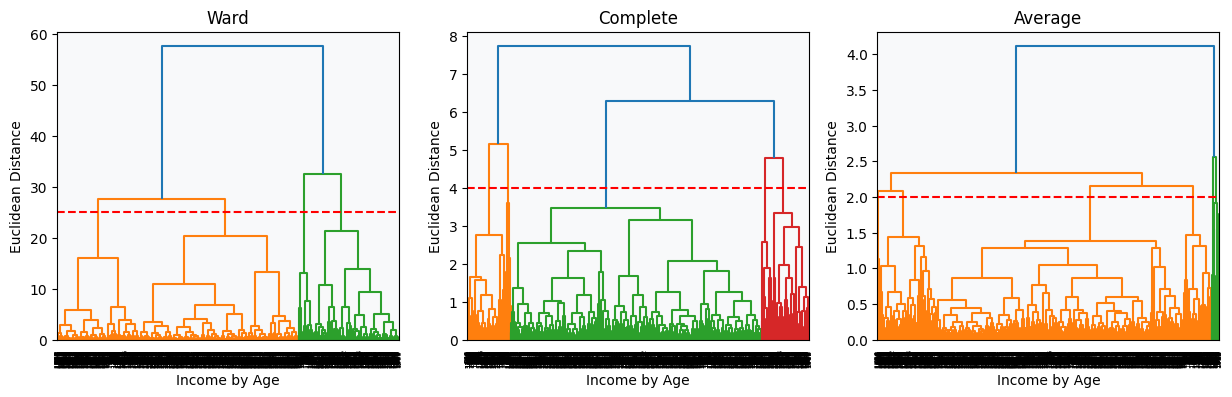

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
dendrogram(ward_model)
plt.title("Ward")
plt.xlabel("Income by Age")
plt.ylabel("Euclidean Distance")
plt.axhline(y=25, color='red', linestyle='--')  # Horizontal cut line


plt.subplot(1,3,2)
dendrogram(complete_model)
plt.title("Complete")
plt.xlabel("Income by Age")
plt.ylabel("Euclidean Distance")
plt.axhline(y=4, color='red', linestyle='--')  # Horizontal cut line


plt.subplot(1,3,3)
dendrogram(average_model)
plt.title("Average")
plt.xlabel("Income by Age")
plt.ylabel("Euclidean Distance")
plt.axhline(y=2, color='red', linestyle='--')  # Horizontal cut line
plt.show()

This code visualizes the hierarchical clustering results using dendrograms for each of the above methods. Each dendrogram shows how observations are merged with the height representing the distance between clusters. Comparing the three plots allows you to see which linkage method produces clearer and more distinct cluster structures for segmentation.

Based on the dendrogram, a clear separation is observed around four clusters in each method. Therefore, four clusters were chosen as an appropraite grouping method.

1.5 Cluster Assignment and Visualization:

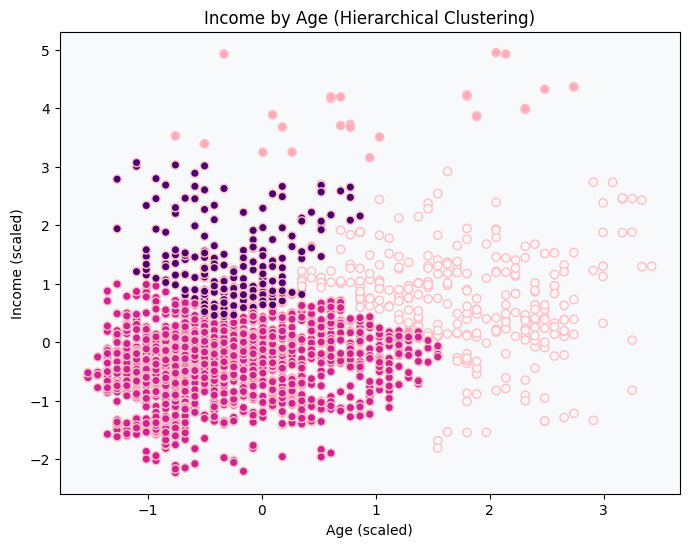

In [ ]:
model = AgglomerativeClustering(n_clusters=4, linkage='complete')
cluster_labels = model.fit_predict(df_scaled)


plt.figure(figsize=(8,6))
plt.scatter(df_scaled['Age'], df_scaled['Income'],
            c=cluster_labels, cmap='RdPu', edgecolor = 'pink')

plt.xlabel("Age (scaled)")
plt.ylabel("Income (scaled)")
plt.title("Income by Age (Hierarchical Clustering)")
plt.show()

This code applies AgglomerativeClustering using complete linkage to group the data into 4 clusters, then assigns a cluster label to each observation. It visualizes the results with a scatterplot of scaled age vs. income. The results display distinct customer groups based on similarities in age and income, making patterns easier to interpret.

PCA was not applied in this case because the dataset was reduced to only two features, which already allowed for clear visualization.

In [ ]:
df['Cluster'] = cluster_labels
df.groupby('Cluster').mean()

,Age,Income,Ward,Complete,Average
Cluster,,,,,
0,56.949275,148474.362319,2.967391,3.0,1.101449
1,49.370370,272544.222222,2.000000,1.0,2.851852
2,32.153951,105302.130109,1.309264,2.0,1.000000
3,33.034934,170251.934498,1.248908,1.0,1.000000


1.5 Interpretation:

This analysis identified four distinct customer segments differenciated by age and income. Cluster 0 is a clear representation of older individuals mid-high income levels, likely individuals nearing retirement. Cluster 1 represents the highest income segment, likely the mid-to-late career proffesionals with high earings. Cluster 2 is the young but mid-income individuals, likely those growing but not at their peak yet. Cluster 3 is the young demographic with high earning incomes, lilely your entrepreneurs, fast-burning professionals, etc.